In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    "daily_return", "log_return_1d", "return_5d", "return_20d",
    "intraday_range", "open_close_return", "volume_change_1d",
    "volume_ratio_20d", "ma_5_ratio", "ma_20_ratio", "ma_60_ratio",
    "volatility_5d", "volatility_10d", "volatility_20d", "volatility_60d",
    "past_max_drawdown_10d", "past_max_drawdown_20d", "past_max_drawdown_60d",
]
TARGET_COL = "future_max_drawdown_10d"

df = pd.read_csv(
    "/kaggle/input/datasets/bogdantrascau/proiect-dnn/features_targets_nasdaq.csv",
    parse_dates=['Date'],
    date_format='%Y-%m-%d'
)
df = df.drop(columns=["Open", "High", "Low", "Close", "Volume"], errors="ignore")

print(df.info())
print(df.head())


2026-06-13 18:46:17.115481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781376377.337234      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781376377.397317      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781376377.901028      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781376377.901065      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781376377.901067      58 computation_placer.cc:177] computation placer alr

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212433 entries, 0 to 212432
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Symbol                   212433 non-null  object        
 1   Date                     212433 non-null  datetime64[ns]
 2   daily_return             212433 non-null  float64       
 3   log_return_1d            212433 non-null  float64       
 4   return_5d                212433 non-null  float64       
 5   return_10d               212433 non-null  float64       
 6   return_20d               212433 non-null  float64       
 7   intraday_range           212433 non-null  float64       
 8   open_close_return        212433 non-null  float64       
 9   volume_change_1d         212433 non-null  float64       
 10  volume_ratio_20d         212433 non-null  float64       
 11  sma_5                    212433 non-null  float64       
 12  sma_10          

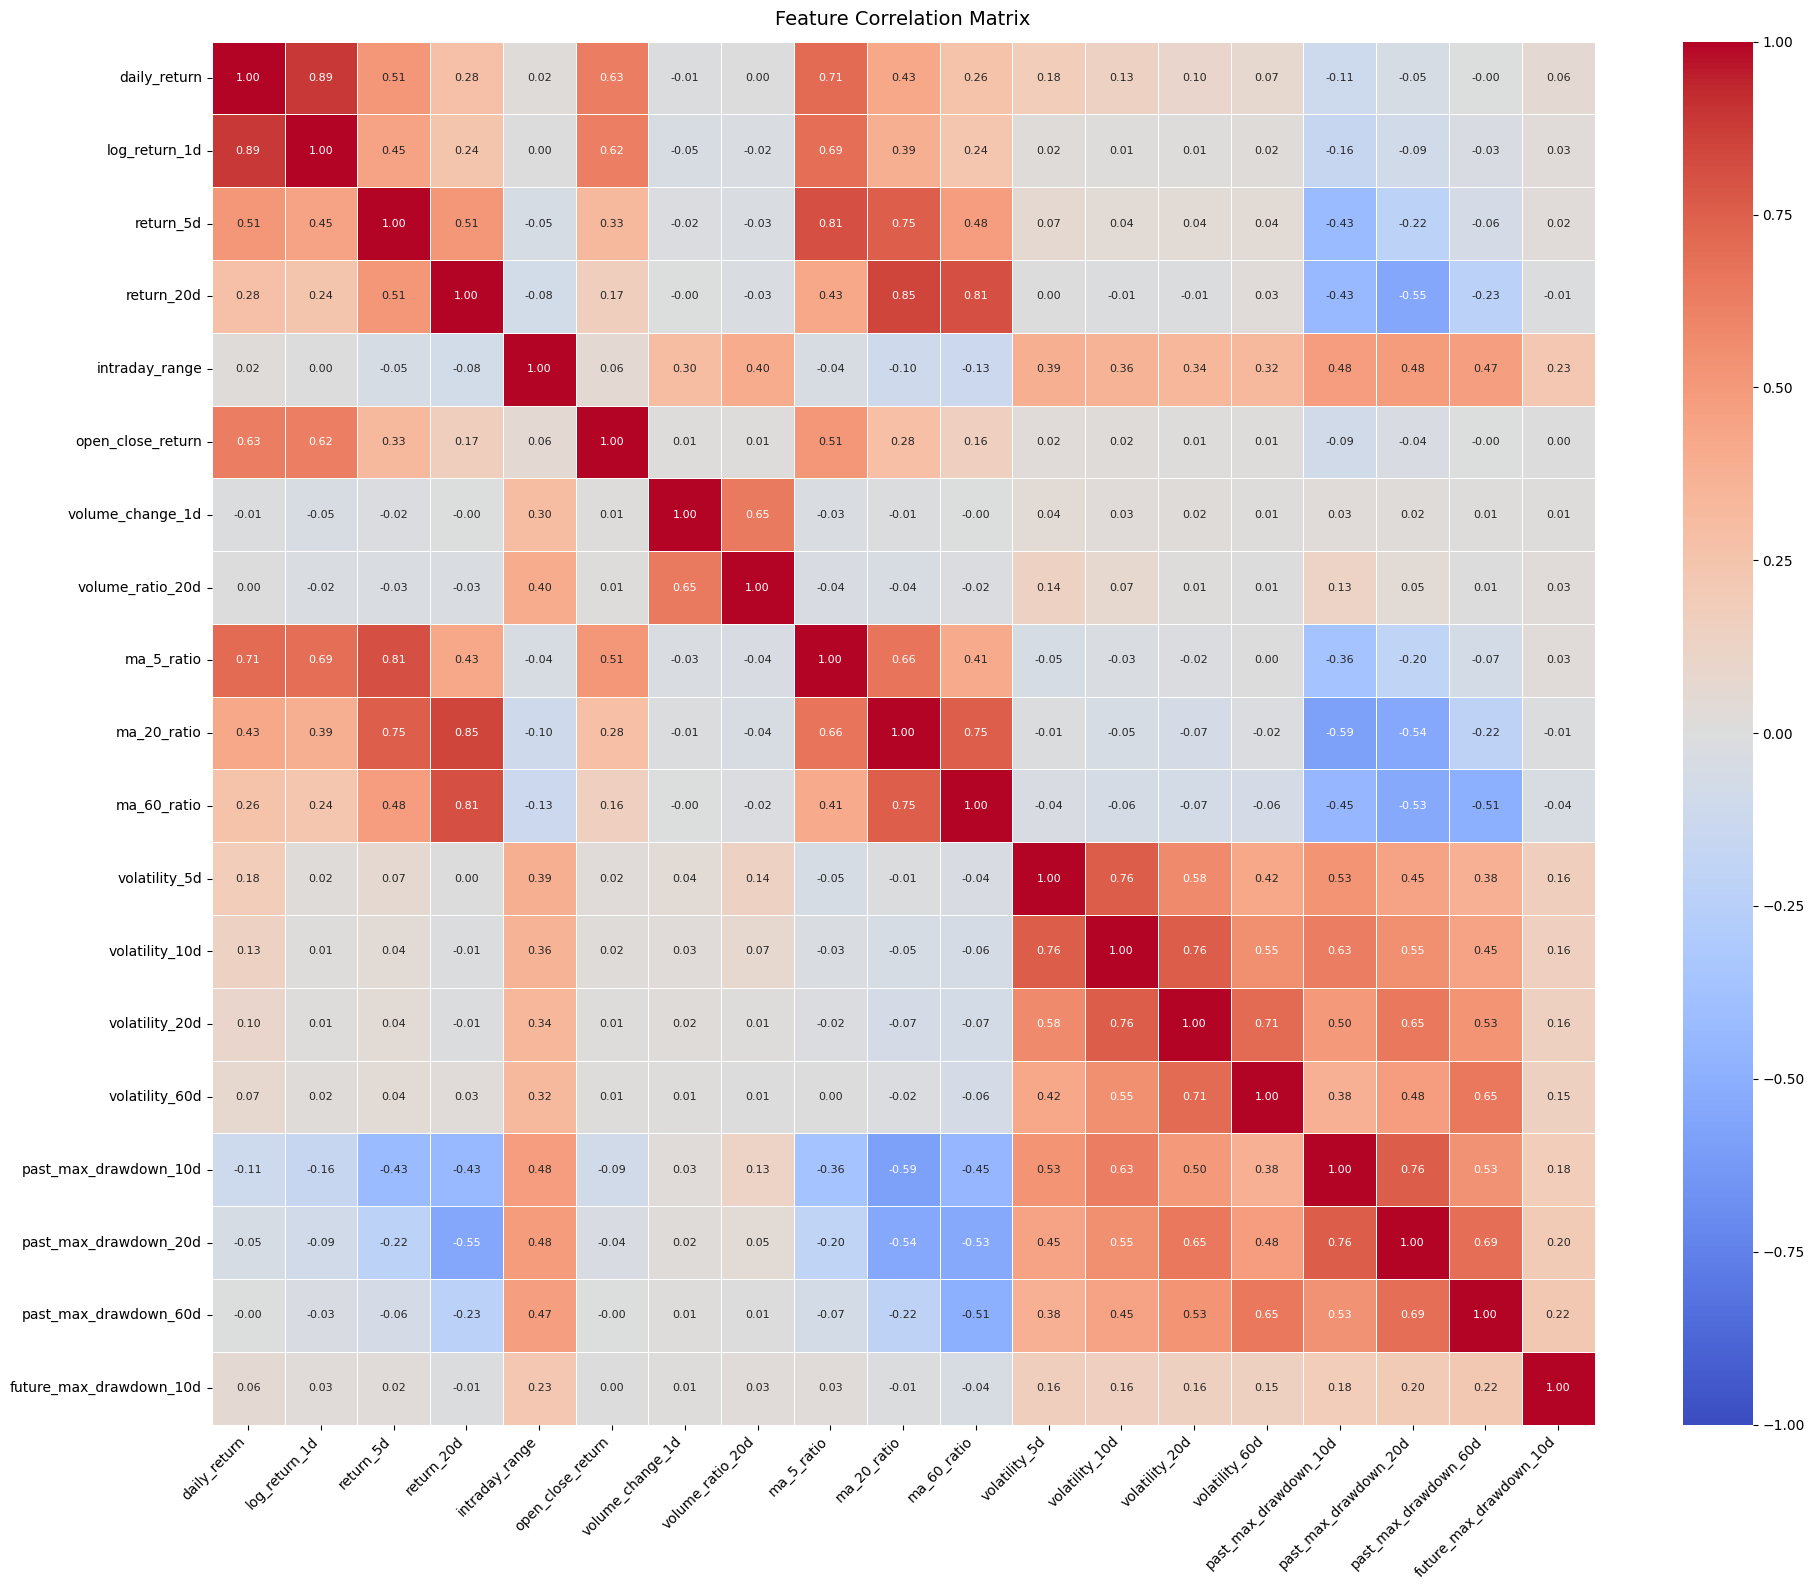

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(20, 16))

corr_matrix = df[FEATURE_COLS + [TARGET_COL]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    vmin = -1,
    vmax = 1
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.title("Feature Correlation Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [3]:
# I. Estimarea dropdown ului pentru o singura companie pe baza regresiei sinusoidale

from scipy.optimize import curve_fit

class CurveEstimator():

    def __init__(self,trend,numberOfEstimators,numberOfOscilations,oscFunctions):
        self.__trend = trend
        self.__nOfEstimators = numberOfEstimators
        self.__nOfOscilations = numberOfOscilations
        self.__oscFunctions = oscFunctions
        self.params = []

    # A f p T
    def __fnTemplate(self,t,*params):
        osc = 0
        trend = 0

        if self.__nOfEstimators > 0:
            trend = self.__trend(t,*params[0:self.__nOfEstimators])
            
        it = 0
        for i in range(self.__nOfEstimators,len(params),3):
            osc += params[i] *self. __oscFunctions[it](params[i+1]*t  + params[i+2])
            it += 1
        
        return trend+osc

    def fit(self,t,y):
        
        estimators = [0.0 for i in range(self.__nOfEstimators-1)]
        estimators.append(np.mean(y))
        oscilations = []
        
        for i in range(self.__nOfOscilations):
            oscilations.append((np.max(y) - np.min(y)) / 4)
            oscilations.append(1.0)
            oscilations.append(0.0)
            
 
        params, _ = curve_fit(self.__fnTemplate,t, y, p0=estimators+oscilations)
        self.params = params
        
    def plot(self,t,df:pd.DataFrame):
        df_temp = df.copy()
        df_temp['pred'] = self.__fnTemplate(t, *self.params)
        df_temp.plot()
        
    def predict(self,t):
        return self.__fnTemplate(t, *self.params)

In [4]:
random_company = df['Symbol'].sample(1).values[0]
df_curve = df[df['Symbol'] == random_company].copy()
df_curve.set_index('Date', inplace=True)
df_curve = df_curve[[TARGET_COL]]
df_curve = df_curve[df_curve.index.year >= 2024]
days = (df_curve.index - df_curve.index[0]).days.values

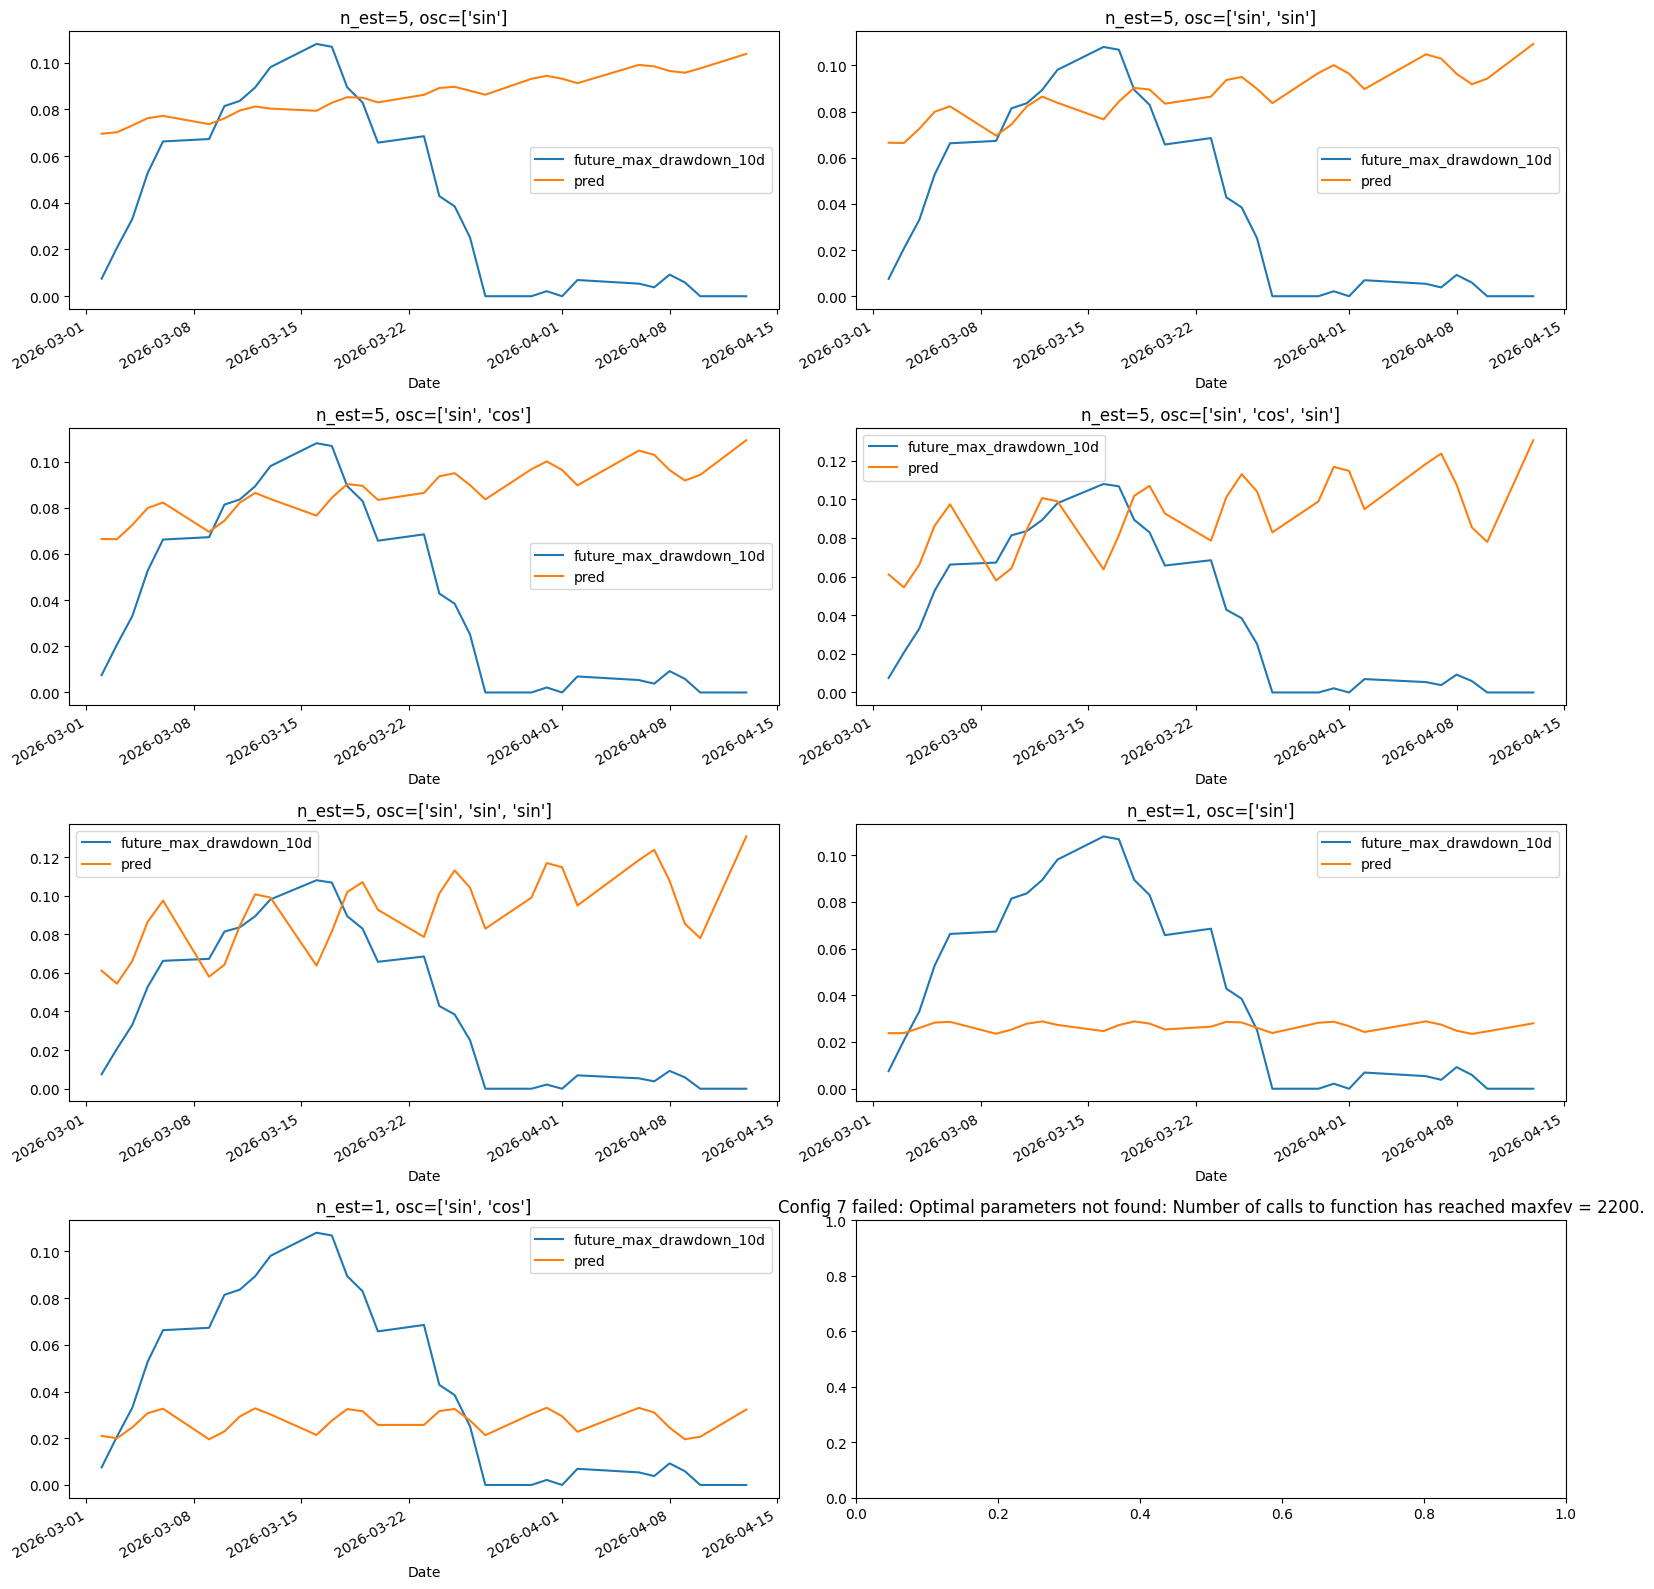

In [5]:
import itertools

def trend(t, a, b, c, d, e):
    return a*t**4 + b*t**3 + c*t**2 + d*t + e
    
trend_configs = [
    (trend, 5, 1, [np.sin]),
    (trend, 5, 2, [np.sin, np.sin]),
    (trend, 5, 2, [np.sin, np.cos]),
    (trend, 5, 3, [np.sin, np.cos, np.sin]),
    (trend, 5, 3, [np.sin, np.sin, np.sin]),
]

flat_trend = lambda t, a: a

flat_configs = [
    (flat_trend, 1, 1, [np.sin]),
    (flat_trend, 1, 2, [np.sin, np.cos]),
    (flat_trend, 1, 3, [np.sin, np.sin, np.sin]),
]

all_configs = trend_configs + flat_configs

n_cols = 2
n_rows = (len(all_configs) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

df_fit = df_curve.iloc[:-30]
df_pred = df_curve.iloc[-30:]

days_fit = (df_fit.index - df_fit.index[0]).days.values
days_pred = (df_pred.index - df_fit.index[0]).days.values

for i, (trend_fn, n_est, n_osc, osc_fns) in enumerate(all_configs):
    try:
        estimator = CurveEstimator(trend_fn, n_est, n_osc, osc_fns)
        estimator.fit(days_fit, df_fit[TARGET_COL].values)

        df_temp = df_pred.copy()
        df_temp['pred'] = estimator.predict(days_pred)
        df_temp.plot(ax=axes[i])

        osc_names = [f.__name__ for f in osc_fns]
        axes[i].set_title(f"n_est={n_est}, osc={osc_names}")
    except Exception as e:
        axes[i].set_title(f"Config {i} failed: {e}")
                          
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

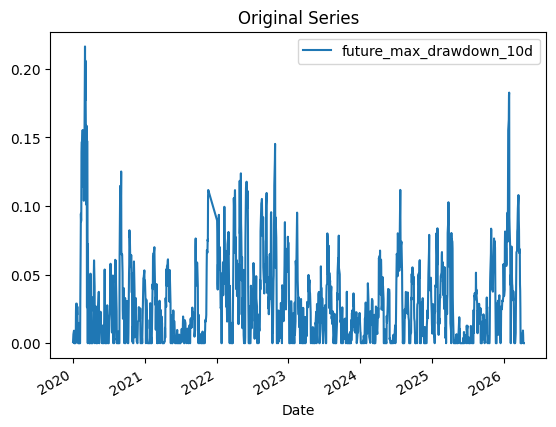

In [6]:
# I. Estimarea dropdown ului pentru o singura companie pe baza SARIMA + NETEZIRE

random_company = df['Symbol'].sample(1).values[0]
df_smooth = df[df['Symbol'] == random_company].copy()
df_smooth.set_index('Date', inplace=True)
df_smooth = df_smooth[[TARGET_COL]]
df_smooth = df_smooth[df_smooth.index.year >= 2020]
df_smooth.plot(title='Original Series')
plt.show()

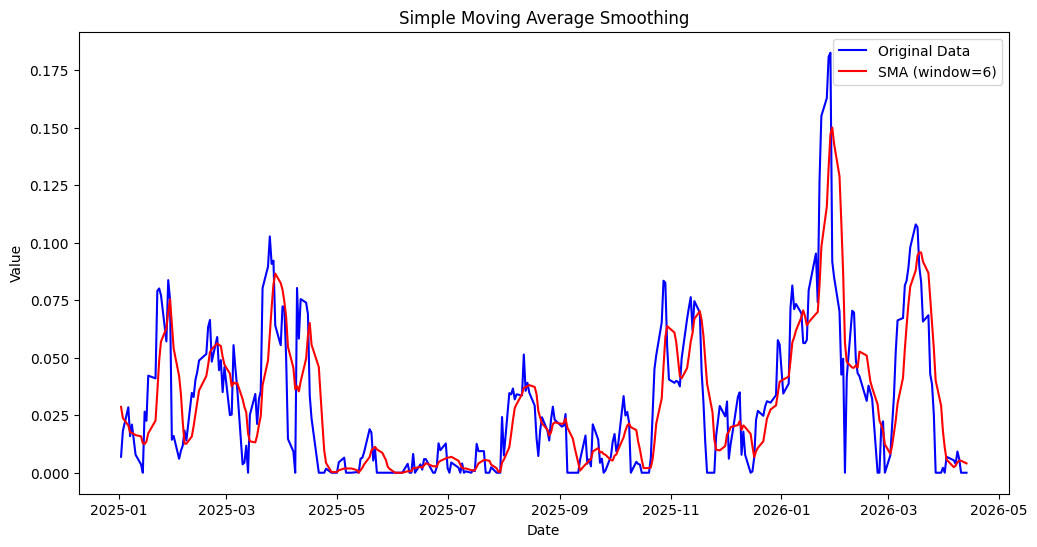

In [7]:
window_size = 6
df_smooth['SMA'] = df_smooth[TARGET_COL].rolling(window=window_size).mean()

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_smooth[df_smooth.index.year >= 2025][TARGET_COL], label='Original Data', color='blue')
plt.plot(df_smooth[df_smooth.index.year >= 2025]['SMA'], label=f'SMA (window={window_size})', color='red')
plt.title('Simple Moving Average Smoothing')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

df_smooth = df_smooth.drop(columns=[TARGET_COL]).dropna()

In [8]:
!pip install arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from arch.unitroot import PhillipsPerron, ADF
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import root_mean_squared_error,r2_score
import math
from statsmodels.tsa.seasonal import STL
from scipy.stats import boxcox
from statsmodels.tsa.deterministic import Fourier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.6 MB/s eta 0:00:00 0:00:01


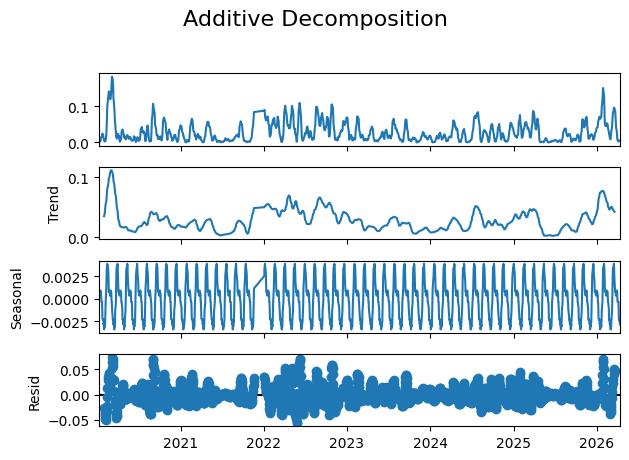

Date
2020-01-09   NaN
2020-01-10   NaN
2020-01-13   NaN
2020-01-14   NaN
2020-01-15   NaN
              ..
2026-04-07   NaN
2026-04-08   NaN
2026-04-09   NaN
2026-04-10   NaN
2026-04-13   NaN
Name: trend, Length: 1544, dtype: float64
     Phillips-Perron Test (Z-tau)    
Test Statistic                 -5.720
P-value                         0.000
Lags                               24
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.
KPSS Statistic: 0.13055417885942894
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
   Augmented Dickey-Fuller Results   
Test Statistic                 -5.001
P-value                         0.000
Lags                               24
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis

/tmp/ipykernel_58/442734623.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, crit = kpss(df_smooth, regression='c', nlags='auto')


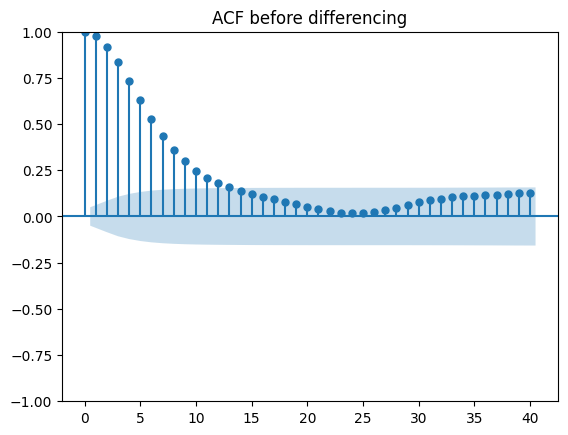

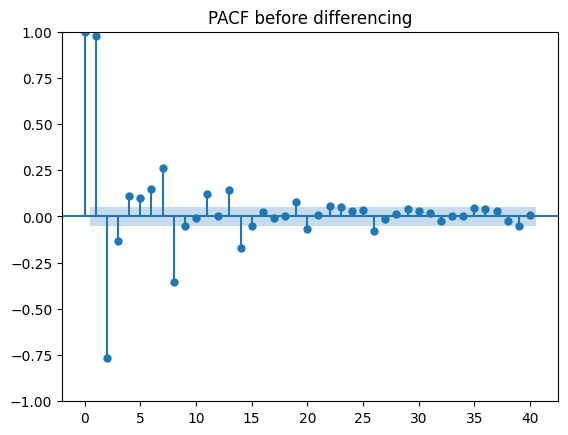

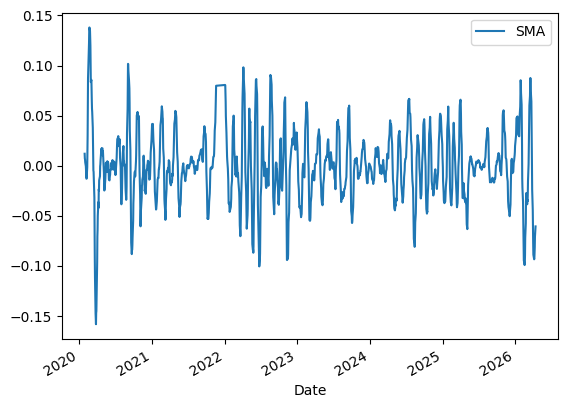

In [9]:
# Seasonal decomposition (additive)
additive_decomposition = seasonal_decompose(df_smooth, model='additive', period=30)
additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(additive_decomposition.trend)


pp_test = PhillipsPerron(df_smooth)
print(pp_test.summary())

kpss_stat, p_value, lags, crit = kpss(df_smooth, regression='c', nlags='auto')
print(f"KPSS Statistic: {kpss_stat}")
print(f"p-value: {p_value}")
print(f"Critical Values: {crit}")

adf = ADF(df_smooth)
print(adf.summary().as_text())

n_lags = min(len(df_smooth) // 4, 40)

plot_acf(df_smooth['SMA'], lags=n_lags)
plt.title("ACF before differencing")
plt.show()

plot_pacf(df_smooth['SMA'], lags=n_lags, method='ywm')
plt.title("PACF before differencing")
plt.show()

df_orig = df_smooth.copy()
df_smooth = df_smooth.diff(12).dropna()
df_smooth.plot()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00a 0:00:01
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[5] intercept   : AIC=-11692.759, Time=2.79 sec
 ARIMA(0,0,0)(0,0,0)[5] intercept   : AIC=-5786.029, Time=0.17 sec
 ARIMA(1,0,0)(1,0,0)[5] intercept   : AIC=-9967.179, Time=0.68 sec
 ARIMA(0,0,1)(0,0,1)[5] intercept   : AIC=inf, Time=2.64 sec
 ARIMA(0,0,0)(0,0,0)[5]             : AIC=-5787.984, Time=0.09 sec
 ARIMA(2,0,2)(0,0,1)[5] intercept   : AIC=-11692.010, Time=0.95 sec
 ARIMA(2,0,2)(1,0,0)[5] intercept   : AIC=-11696.014, Time=2.95 sec
 ARIMA(2,0,2)(0,0,0)[5] intercept   : AIC=-11694.010, Time=1.20 sec
 ARIMA(2,0,2)(2,0,0)[5] intercept   : AIC=-11690.117, Time=4.23 sec
 ARIMA(2,0,2)(2,0,1)[5] intercept   : AIC=-11694.288, Time=4.69 sec
 ARIMA(1,0,2)(1,0,0)[5] intercept   : AIC=-11268.766, Time=2.84 sec
 ARIMA(2,0,1)(1,0,0)[5] intercept   : AIC=-11681.210, Time=1.92 sec
 ARIMA(3,0,2)(1,0,0)[5] intercept   : AIC=-11693.223, Time=2.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


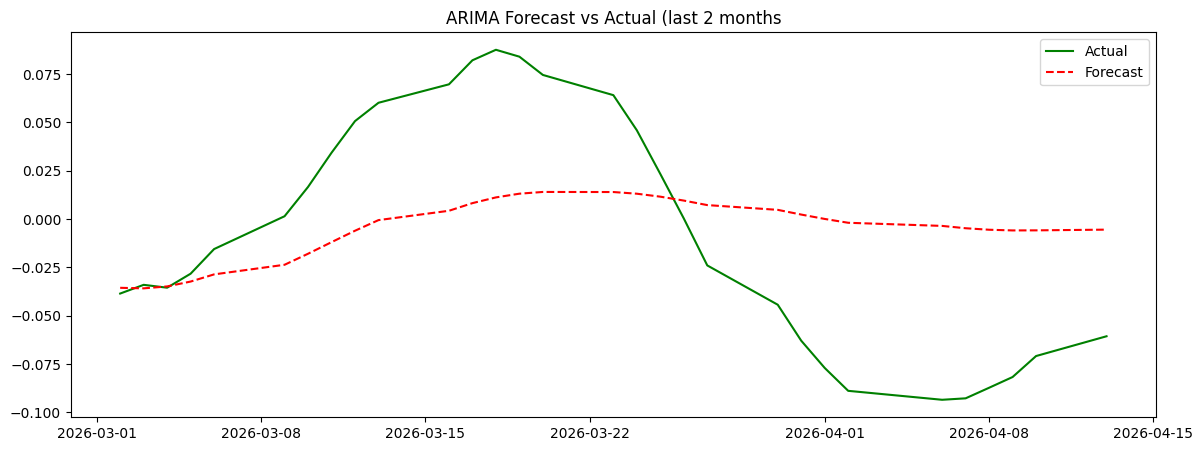

In [10]:
!pip install pmdarima
from pmdarima import auto_arima

df_fit = df_smooth.iloc[:-30]
df_pred = df_smooth.iloc[-30:]

model = auto_arima(
    df_fit['SMA'],
    d=0,
    seasonal=True,
    m=5,
    information_criterion='aic',
    stepwise=True,
    trace=True
)

forecast = model.predict(n_periods=30)

plt.figure(figsize=(14, 5))
plt.plot(df_pred.index, df_pred['SMA'], label='Actual', color='green')
plt.plot(df_pred.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual (last 2 months')
plt.legend()
plt.show()

In [11]:
#III. Analiza serii de timp multivariate pentru o singura companie
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

random_company = df['Symbol'].sample(1).values[0]
df_multi = df[df['Symbol'] == random_company].copy().drop(columns=['Symbol'])
df_multi = df_multi[[TARGET_COL, "Date"] + FEATURE_COLS]
df_multi.set_index('Date', inplace=True)
df_multi = df_multi[df_multi.index.year >= 2020]

df_multi.info()

# Test de cointegrare
for i in range(len(df_multi.columns)-1):
    for j in range(i+1, len(df_multi.columns)):
        col1 = df_multi.columns[i]
        col2 = df_multi.columns[j]
        if col1 != TARGET_COL and col2 != TARGET_COL:
            continue
        
        coint_t, p_value, crit_values = coint(df_multi[col1], df_multi[col2])
        print(f"{col1} si {col2}")
        print("\nCointegration Test Result:")
        print(f"T-statistic: {coint_t}")
        print(f"P-value: {p_value}")
        print(f"Critical Values: {crit_values}")
        if p_value < 0.05:
            print("✅ The series are cointegrated.")
        else:
            print("❌ The series are NOT cointegrated.")

for it in df_multi.columns:
    chk = adfuller(df_multi[it],autolag='AIC')
    if chk[1] < 0.05:
        print(f"{it} e stationara")
    else:
        print(f"{it} e nestationara")  


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1549 entries, 2020-01-01 to 2026-04-13
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   future_max_drawdown_10d  1549 non-null   float64
 1   daily_return             1549 non-null   float64
 2   log_return_1d            1549 non-null   float64
 3   return_5d                1549 non-null   float64
 4   return_20d               1549 non-null   float64
 5   intraday_range           1549 non-null   float64
 6   open_close_return        1549 non-null   float64
 7   volume_change_1d         1549 non-null   float64
 8   volume_ratio_20d         1549 non-null   float64
 9   ma_5_ratio               1549 non-null   float64
 10  ma_20_ratio              1549 non-null   float64
 11  ma_60_ratio              1549 non-null   float64
 12  volatility_5d            1549 non-null   float64
 13  volatility_10d           1549 non-null   float64
 14  volati

In [12]:
df_train = df_multi.iloc[:-30]
df_test = df_multi.iloc[-30:]

model = VAR(df_train)

lag_results = model.select_order(maxlags=15)
print(lag_results.summary())

best_lag = lag_results.aic
print(f"Best lag by AIC: {best_lag}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -146.6      -146.5   2.125e-64      -146.6
1       -185.7      -184.3   2.352e-81      -185.2
2       -186.8      -184.2   7.712e-82      -185.8
3       -189.4     -185.5*   5.762e-83      -187.9
4       -190.0      -184.9   2.941e-83      -188.1
5       -191.0      -184.5   1.144e-83     -188.6*
6       -191.1      -183.4   9.857e-84      -188.3
7       -191.2      -182.2   9.338e-84      -187.8
8       -191.4      -181.1   7.628e-84      -187.6
9       -191.8      -180.2   5.243e-84      -187.5
10      -192.2      -179.3   3.559e-84      -187.4
11      -192.5      -178.4   2.488e-84      -187.3
12      -192.5      -177.2   2.543e-84      -186.8
13      -192.4      -175.8   2.842e-84      -186.2
14      -192.3      -174.4   3.189e-84      -185.7
15     -192.6*      -173.4  2.486e-84*      -185.4
-------------------------------

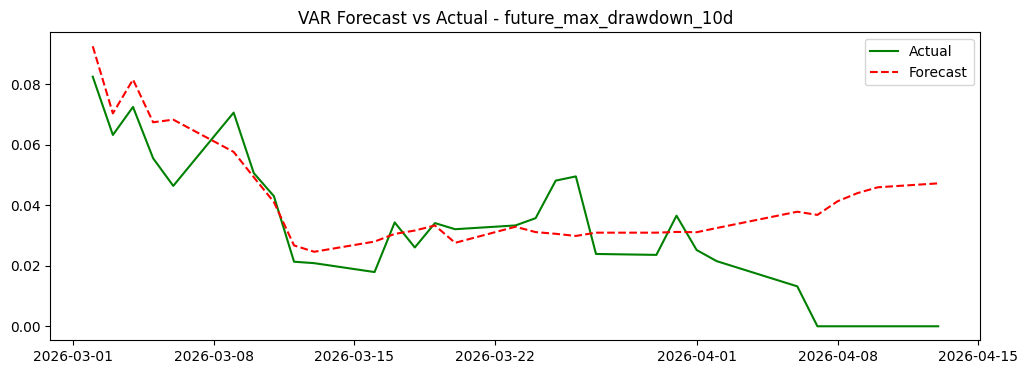

In [13]:
fitted = model.fit(best_lag)

forecast_input = df_train.values[-best_lag:]
forecast = fitted.forecast(forecast_input, steps=30)
forecast_df = pd.DataFrame(forecast, index=df_test.index, columns=df_multi.columns)

plt.figure(figsize=(12, 4))
plt.plot(df_test.index, df_test[TARGET_COL], label='Actual', color='green')
plt.plot(forecast_df.index, forecast_df[TARGET_COL], label='Forecast', color='red', linestyle='--')
plt.title(f'VAR Forecast vs Actual - {TARGET_COL}')
plt.legend()
plt.show()

In [14]:
# IV. Regresie cu date de tip panel
!pip install linearmodels
from linearmodels.panel import PanelOLS

window_size = 6
df_panel = df.copy()
df_panel[TARGET_COL] = df_panel[TARGET_COL].rolling(window=window_size).mean().dropna()
df_panel = df_panel[df_panel['Date'].dt.year >= 2020]
df_panel = df_panel.set_index(['Symbol', 'Date'])
df_panel = df_panel[[TARGET_COL] + FEATURE_COLS].dropna()

df_panel = df_panel.dropna()

split_date = df_panel.index.get_level_values('Date').unique().sort_values()[-30]

df_train = df_panel[df_panel.index.get_level_values('Date') < split_date]
df_test  = df_panel[df_panel.index.get_level_values('Date') >= split_date]

features = FEATURE_COLS
exog_train = df_train[FEATURE_COLS]
endog_train = df_train[TARGET_COL]

model = PanelOLS(endog_train, exog_train, entity_effects=True)
fitted = model.fit(cov_type='robust')
print(fitted.summary)

preds = fitted.predict(df_test[features])
df_test = df_test.copy()
df_test['pred'] = preds.values

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.2 MB/s eta 0:00:00
                             PanelOLS Estimation Summary                             
Dep. Variable:     future_max_drawdown_10d   R-squared:                        0.2662
Estimator:                        PanelOLS   R-squared (Between):             -68.172
No. Observations:                    66026   R-squared (Within):               0.2662
Date:                     Sat, Jun 13 2026   R-squared (Overall):             -29.197
Time:                             18:48:04   Log-likelihood                 1.122e+05
Cov. Estimator:                     Robust                                           
                                             F-statistic:                      1329.3
Entities:                               49   P-value                           0.0000
Avg Obs:                            1347.5   Distribution:

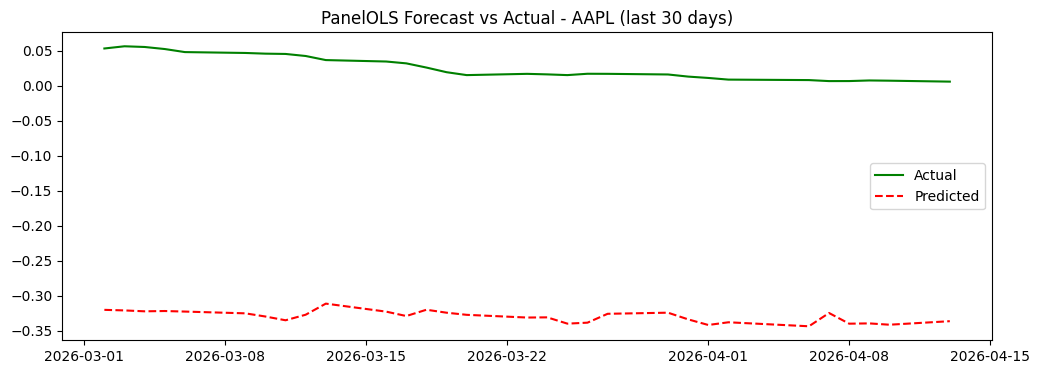

In [15]:
sample_company = df_test.index.get_level_values('Symbol').unique()[0]
df_sample = df_test.xs(sample_company, level='Symbol')

plt.figure(figsize=(12, 4))
plt.plot(df_sample.index, df_sample[TARGET_COL], label='Actual', color='green')
plt.plot(df_sample.index, df_sample['pred'], label='Predicted', color='red', linestyle='--')
plt.title(f'PanelOLS Forecast vs Actual - {sample_company} (last 30 days)')
plt.legend()
plt.show()

In [16]:
# V. Predictie folosing retele neuronale
import tensorflow as tf
from sklearn.preprocessing import StandardScaler


SEQ_LEN = 30

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

all_X_train, all_y_train = [], []
all_X_test,  all_y_test  = [], []
test_indices = {}

scaler = StandardScaler()

for company in df_panel.index.get_level_values('Symbol').unique():
    df_company = df_panel.xs(company, level='Symbol').sort_index()
    df_company = df_company[features + [TARGET_COL]].dropna()

    if len(df_company) < SEQ_LEN + 30:
        continue

    data_scaled = scaler.fit_transform(df_company.values)

    split_idx = len(df_company) - 30
    train_data = data_scaled[:split_idx]
    test_data  = data_scaled[split_idx - SEQ_LEN:]

    X_train, y_train = make_sequences(train_data, SEQ_LEN)
    X_test,  y_test  = make_sequences(test_data,  SEQ_LEN)

    all_X_train.append(X_train)
    all_y_train.append(y_train)
    all_X_test.append(X_test)
    all_y_test.append(y_test)
    test_indices[company] = df_company.index[-30:]

X_train = np.concatenate(all_X_train, axis=0)
y_train = np.concatenate(all_y_train, axis=0)
X_test  = np.concatenate(all_X_test,  axis=0)
y_test  = np.concatenate(all_y_test,  axis=0)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (64556, 30, 18), Test: (1470, 30, 18)


In [ ]:
def buildLSTM(seq_len, n_features):
    model_lstm = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
    model_lstm.summary()
    return model_lstm

def buildGRU(seq_len, n_features):
    model_gru = tf.keras.Sequential([
        tf.keras.layers.GRU(64, return_sequences=True, input_shape=(seq_len, n_features)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.GRU(32),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])
    model_gru.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
    model_gru.summary()
    return model_gru

def buildCNNGRU(seq_len, n_features, hidden_size=64, dropout=0.2):
    inputs = tf.keras.Input(shape=(seq_len, n_features))
    
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GRU(hidden_size, return_sequences=True, dropout=dropout)(x)
    x = tf.keras.layers.GRU(hidden_size // 2, dropout=dropout)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(1)(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=tf.keras.losses.Huber(), metrics=['mae'])
    model.summary()
    return model

def buildCNNBiGRUAttention(
    seq_len,
    n_features,
    dropout=0.3,
    learning_rate=1e-3
):
    inputs = tf.keras.Input(shape=(seq_len, n_features))

    x = tf.keras.layers.Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dropout(dropout)(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            128,
            return_sequences=True,
            dropout=dropout
        )
    )(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.GRU(
            64,
            return_sequences=True,
            dropout=dropout
        )
    )(x)

    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=dropout
    )(x, x)

    x = tf.keras.layers.Add()([x, attn])

    x = tf.keras.layers.LayerNormalization()(x)

    avg_pool = tf.keras.layers.GlobalAveragePooling1D()(x)
    max_pool = tf.keras.layers.GlobalMaxPooling1D()(x)

    x = tf.keras.layers.Concatenate()([avg_pool, max_pool])

    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    model.summary()
    return model



def train(model, X_train, y_train, save_path, epochs=50, batch_size=256, validation_split=0.1, patience=3):
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=[
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=patience, factor=0.5, verbose=1),
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience * 2 + 1, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(save_path, monitor="val_loss", save_best_only=True, verbose=1),
        ]
    )
    return history


def plot(history, model, X_test, y_test, all_X_test, test_indices, scaler, features, sample_company=None):
    plt.figure(figsize=(10, 3))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('LSTM Training Loss')
    plt.legend()
    plt.show()

    if sample_company is None:
        sample_company = list(test_indices.keys())[0]
    company_idx = list(test_indices.keys()).index(sample_company)

    start = sum(len(all_X_test[i]) for i in range(company_idx))
    end   = start + len(all_X_test[company_idx])

    X_company = X_test[start:end]
    y_company = y_test[start:end]
    preds = model.predict(X_company).flatten()

    n_features = len(features) + 1
    dummy = np.zeros((len(preds), n_features))
    dummy[:, -1] = preds
    preds_unscaled = scaler.inverse_transform(dummy)[:, -1]

    dummy2 = np.zeros((len(y_company), n_features))
    dummy2[:, -1] = y_company
    actual_unscaled = scaler.inverse_transform(dummy2)[:, -1]

    plt.figure(figsize=(12, 4))
    plt.plot(test_indices[sample_company], actual_unscaled, label='Actual', color='green')
    plt.plot(test_indices[sample_company], preds_unscaled, label='Predicted', color='red', linestyle='--')
    plt.title(f'Model Forecast vs Actual - {sample_company} (last 30 days)')
    plt.legend()
    plt.show()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1781376486.361371      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781376486.367346      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GPUs in use: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 548,865 (2.09 MB)

 Non-trainable params: 1,024 (4.00 KB)


Training LSTM
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:

I0000 00:00:1781376492.201527     181 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781376493.003749     182 cuda_dnn.cc:529] Loaded cuDNN version 91002


113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2931 - mae: 0.6110INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from None to 0.27203, saving model to /kaggle/working/saved_models/LSTM.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/LSTM.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.2761 - mae: 0.5862 - val_loss: 0.2720 - val_mae: 0.5911 - learning_rate: 0.0010
Epoch 2/50
111/114 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2574 - mae: 0.5594
Epoch 2: val_loss improved from 0.27203 to 0.26680, saving model to /kaggle/working/saved_models/LSTM.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/LSTM.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.2552 - mae: 0.5561 -

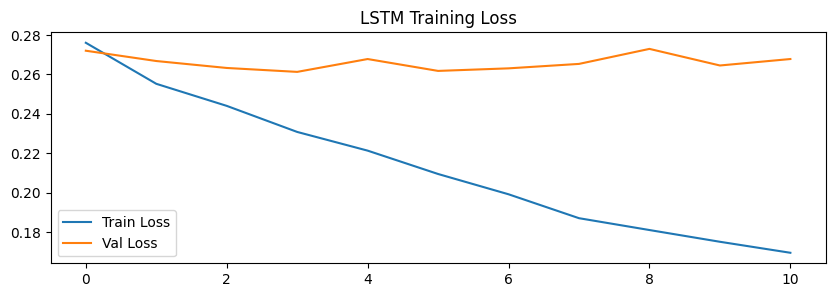

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step


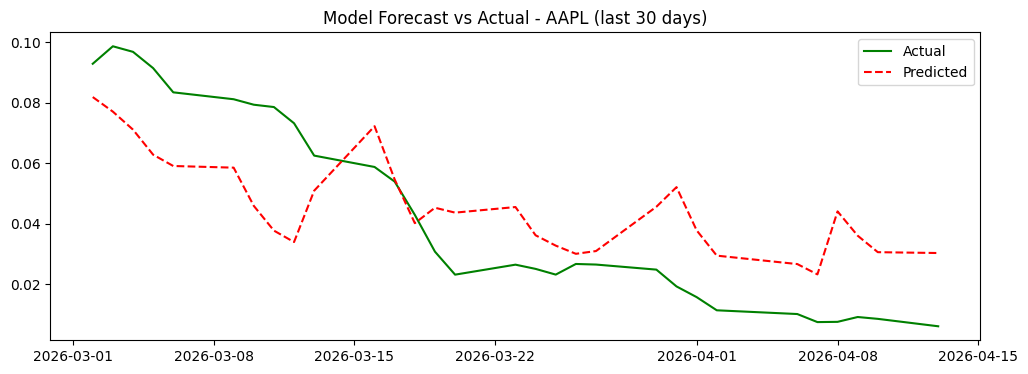

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training GRU
Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
110/114 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2875 - mae: 0.5991
Epoch 1: val_loss improved from None to 0.27196, saving model to /kaggle/working/saved_models/GRU.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/GRU.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.2730 - mae: 0.5806 - val_loss: 0.2720 - val_mae: 0.5879 - learning_rate: 0.0010
Epoch 2/50
110/114 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2619 - mae: 0.5666
Epoch 2: val_loss improved from 0.27196 to 0.26981, saving model to /kaggle/working/saved_models/GRU.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/GRU.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.2618 - mae: 0.5654 - val_loss: 0.2698 - val_mae: 0.5847 - learning_rate: 0.0010

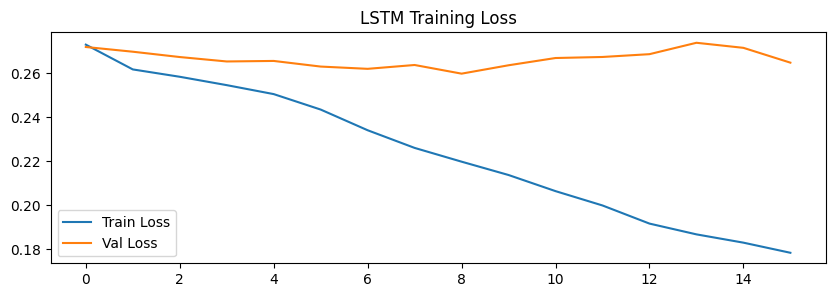

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step


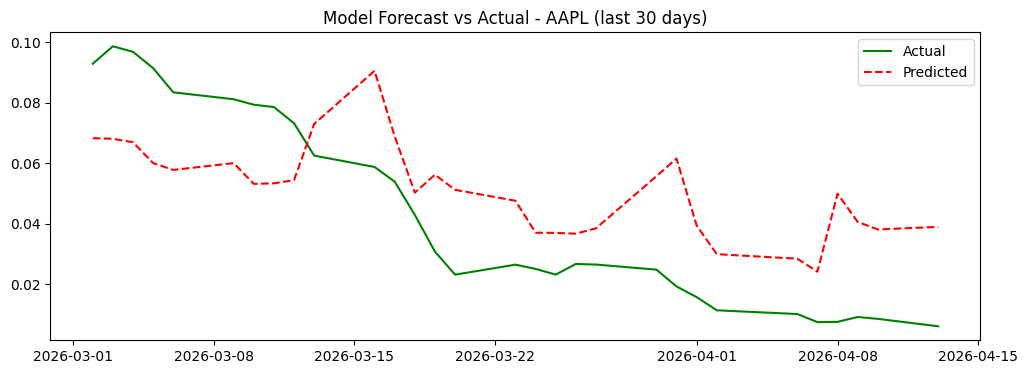

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Training CNNGRU
Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 18 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2838 - mae: 0.5962
Epoch 1: val_loss improved from None to 0.28249, saving model to /kaggle/working/saved_models/CNNGRU.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/CNNGRU.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.2738 - mae: 0.5820 - val_loss: 0.2825 - val_mae: 0.6135 - learning_rate: 0.0010
Epoch 2/50
112/114 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2589 - mae: 0.5609
Epoch 2: val_loss improved from 0.28249 to 0.26888, saving model to /kaggle/working/saved_models/CNNGRU.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/CNNGRU.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.2529 - mae: 0.5531 - val_loss: 0.2689 - val_mae: 0.5879 - learn

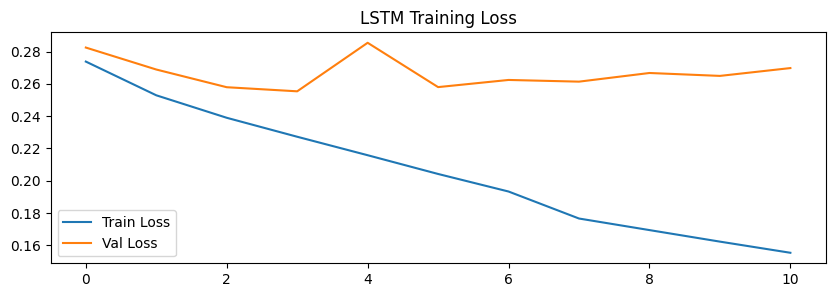

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step


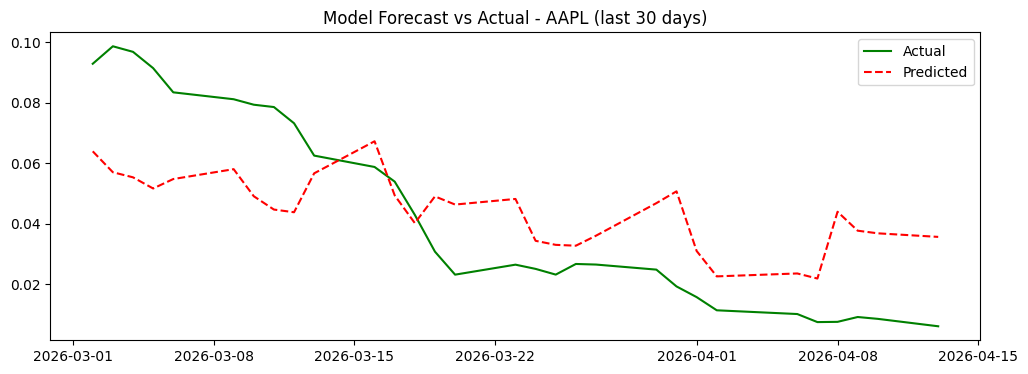

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step

Training CNNBiGRUAttention
Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 38 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5673 - mae: 0.9457
Epoch 1: val_loss improved from None to 0.33628, saving model to /kaggle/working/saved_models/CNNBiGRUAttention.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/CNNBiGRUAttention.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 0.4528 - mae: 0.8103 - val_loss: 0.3363 - val_mae: 0.6640 - learning_rate: 0.0010
Epoch 2/50
113/114 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3290 - mae: 0.6570
Epoch 2: val_loss improved from 0.33628 to 0.30703, saving model to /kaggle/working/saved_models/CNNBiGRUAttention.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/CNNBiGRUAttention.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.3202 - 

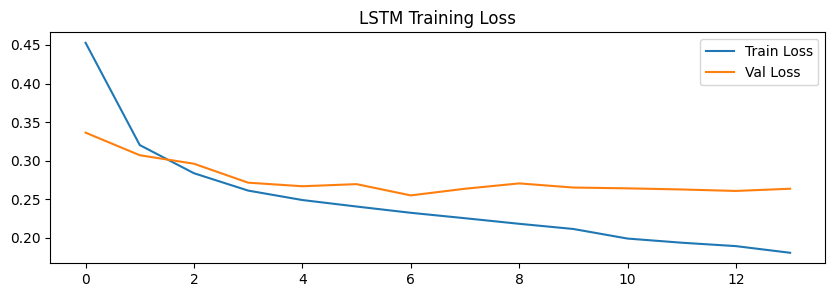

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


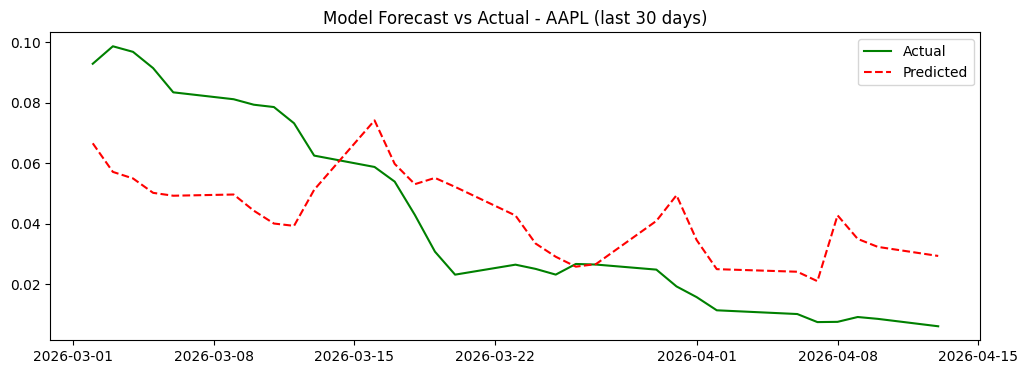

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

=== Model Comparison ===
                        MSE       MAE      RMSE
CNNBiGRUAttention  0.004414  0.038101  0.066435
GRU                0.004501  0.037820  0.067089
LSTM               0.004507  0.037960  0.067133
CNNGRU             0.004605  0.038672  0.067862


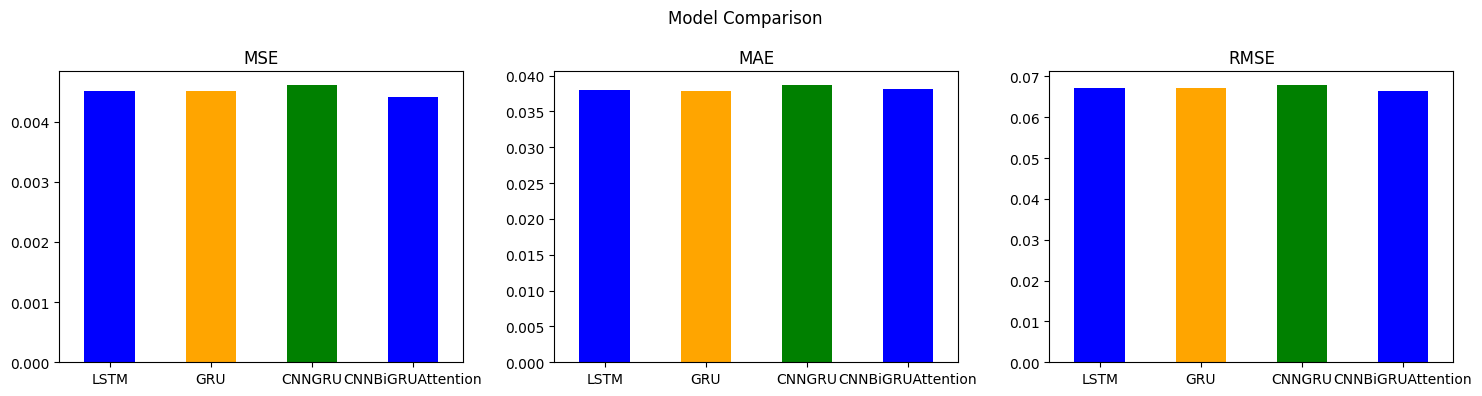

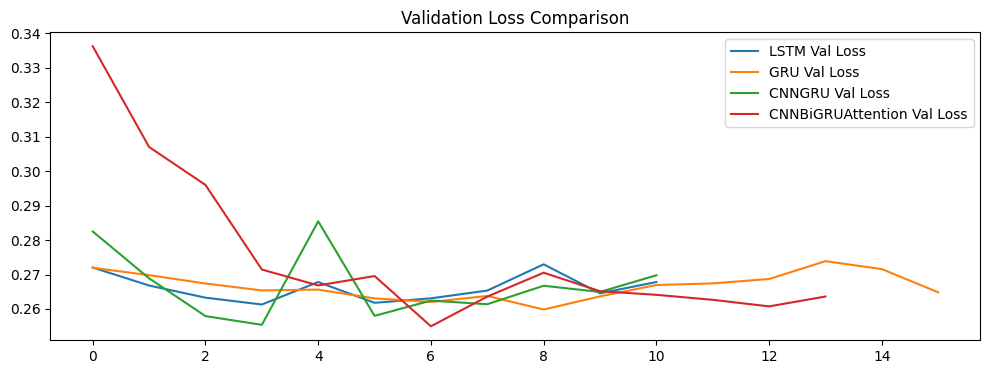

Metrics saved to /kaggle/working/saved_models/metrics.csv


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

SAVE_DIR = "/kaggle/working/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

strategy = tf.distribute.MirroredStrategy()
print(f"GPUs in use: {strategy.num_replicas_in_sync}")
NUM_GPUS = strategy.num_replicas_in_sync

with strategy.scope():
    model_configs = {
        'LSTM':   buildLSTM(seq_len=SEQ_LEN,   n_features=X_train.shape[2]),
        'GRU':    buildGRU(seq_len=SEQ_LEN,    n_features=X_train.shape[2]),
        'CNNGRU': buildCNNGRU(seq_len=SEQ_LEN, n_features=X_train.shape[2]),
        'CNNBiGRUAttention': buildCNNBiGRUAttention(seq_len=SEQ_LEN, n_features=X_train.shape[2])
    }

histories = {}
metrics   = {}

for name, model in model_configs.items():
    print(f"\n{'='*40}\nTraining {name}\n{'='*40}")

    history = train(model, X_train, y_train, save_path = os.path.join(SAVE_DIR, f"{name}.keras"), batch_size=256 * NUM_GPUS)
    histories[name] = history

    plot(history, model, X_test, y_test, all_X_test, test_indices, scaler, features)

    preds = model.predict(X_test).flatten()
    n_feat = len(features) + 1

    dummy = np.zeros((len(preds), n_feat))
    dummy[:, -1] = preds
    preds_unscaled = scaler.inverse_transform(dummy)[:, -1]

    dummy2 = np.zeros((len(y_test), n_feat))
    dummy2[:, -1] = y_test
    actual_unscaled = scaler.inverse_transform(dummy2)[:, -1]

    metrics[name] = {
        'MSE':  mean_squared_error(actual_unscaled, preds_unscaled),
        'MAE':  mean_absolute_error(actual_unscaled, preds_unscaled),
        'RMSE': np.sqrt(mean_squared_error(actual_unscaled, preds_unscaled)),
    }

metrics_df = pd.DataFrame(metrics).T
print("\n=== Model Comparison ===")
print(metrics_df.sort_values('RMSE'))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MSE', 'MAE', 'RMSE']):
    metrics_df[metric].plot(kind='bar', ax=ax, color=['blue', 'orange', 'green'])
    ax.set_title(metric)
    ax.set_xticklabels(metrics_df.index, rotation=0)
plt.suptitle('Model Comparison')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'{name} Val Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()

metrics_df.to_csv(os.path.join(SAVE_DIR, 'metrics.csv'))
print(f"Metrics saved to {SAVE_DIR}/metrics.csv")

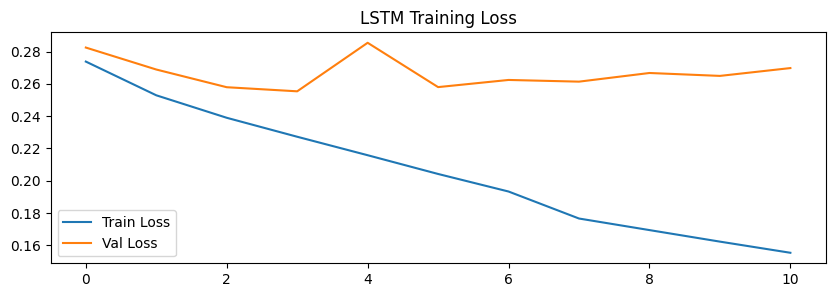

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


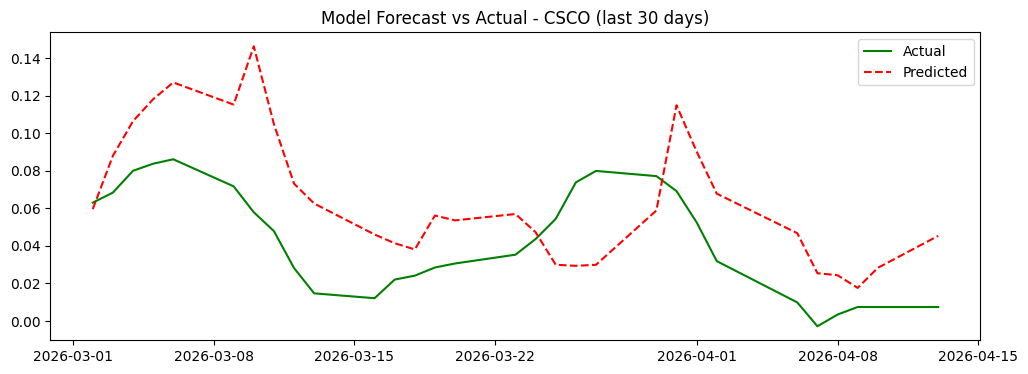

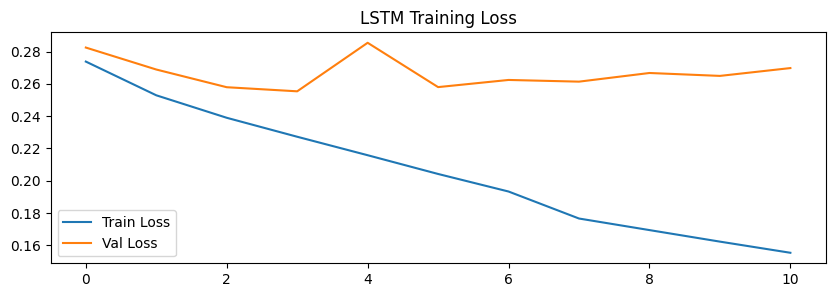

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


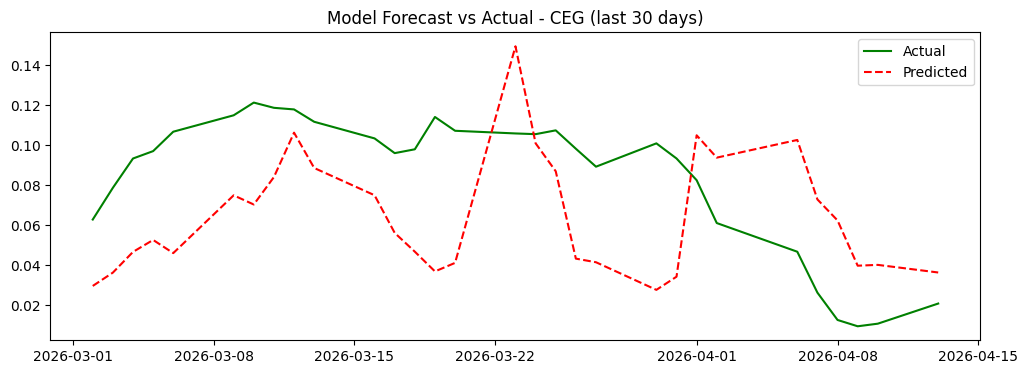

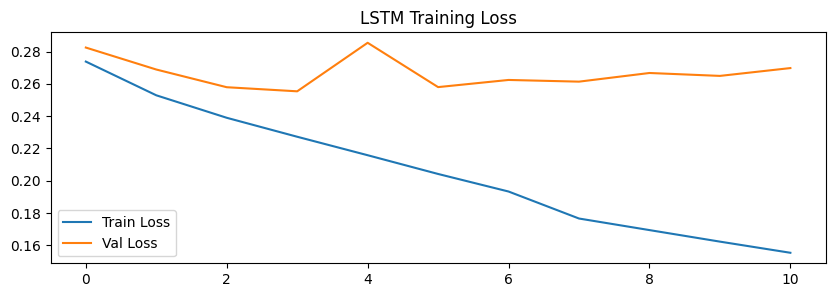

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


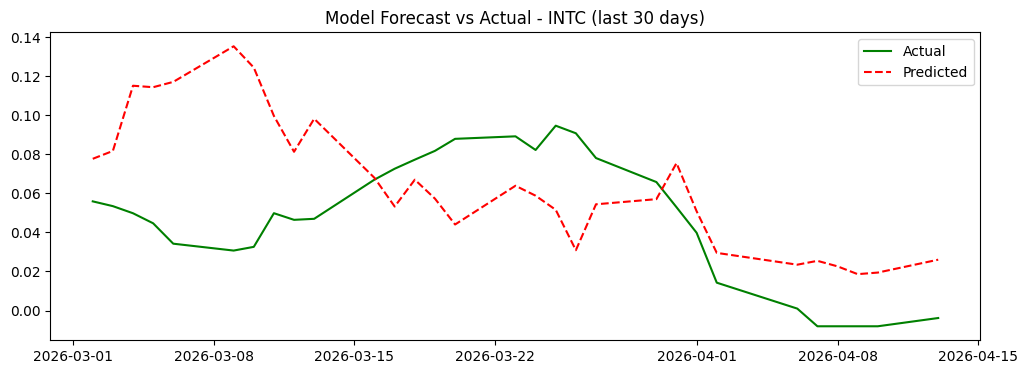

In [19]:
sample_companies = list(test_indices.keys())
random_companies = np.random.choice(sample_companies, size=3, replace=False)

for company in random_companies:
    plot(histories['CNNGRU'], model_configs['CNNGRU'], X_test, y_test, all_X_test, test_indices, scaler, features, sample_company=company)